> **Course: AIML ZG528 AI and ML for Robotics**

>  **Author: Sangeetha Viswanathan**
sangeetha.viswanathan@pilani.bits-pilani.ac.in

> **Objective**: Implement Evolutionary Algorithms in Path Planning

# Genetic Algorithm Based Path Planning for Warehouse Navigation
## Using PyBullet Simulation

This notebook demonstrates:
- Genetic Algorithm implementation for path planning
- PyBullet physics simulation
- Warehouse environment with obstacles
- Robot navigation visualization

## 1. Install Dependencies

In [ ]:
# Install PyBullet
!pip install pybullet matplotlib numpy

print("\n✓ All dependencies installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 9.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pybullet: filename=pybullet-3.2.7-cp312-cp312-linux_x86_64.whl size=99873158 sha256=0329811f6d9c55c62ff86fc62258544745a901da1f898b3c20d271cf5d86cba1
  Stored in directory: /root/.cache/pip/wheels/72/95/1d/b336e5ee612ae9a019bfff4dc0bedd100ee6f0570db205fdf8
Successfully built pybullet

✓ All dependencies installed successfully!


## 2. Import Libraries

In [ ]:
import numpy as np
import pybullet as p
import pybullet_data
import time
import random
from typing import List, Tuple
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from IPython.display import clear_output

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 3. Genetic Algorithm Path Planner Class

In [ ]:
class GeneticPathPlanner:
    """Genetic Algorithm for finding optimal path in warehouse"""

    def __init__(self, start: Tuple[float, float], goal: Tuple[float, float],
                 obstacles: List[Tuple[float, float, float]],
                 warehouse_bounds: Tuple[float, float, float, float],
                 population_size: int = 100,
                 num_waypoints: int = 8,
                 generations: int = 50):
        self.start = np.array(start)
        self.goal = np.array(goal)
        self.obstacles = obstacles
        self.bounds = warehouse_bounds
        self.population_size = population_size
        self.num_waypoints = num_waypoints
        self.generations = generations
        self.population = []
        self.best_path = None
        self.fitness_history = []

    def initialize_population(self):
        """Create initial random population of paths"""
        self.population = []
        for _ in range(self.population_size):
            waypoints = []
            for _ in range(self.num_waypoints):
                x = random.uniform(self.bounds[0], self.bounds[1])
                y = random.uniform(self.bounds[2], self.bounds[3])
                waypoints.append([x, y])

            path = [self.start.tolist()] + waypoints + [self.goal.tolist()]
            self.population.append(np.array(path))

    def calculate_fitness(self, path: np.ndarray) -> float:
        """Calculate fitness (lower is better)"""
        # Path length
        length = 0
        for i in range(len(path) - 1):
            length += np.linalg.norm(path[i+1] - path[i])

        # Collision penalty
        collision_penalty = 0
        for i in range(len(path) - 1):
            for obs_x, obs_y, obs_radius in self.obstacles:
                obs_pos = np.array([obs_x, obs_y])
                collision_dist = self._point_to_segment_distance(
                    obs_pos, path[i], path[i+1]
                )
                if collision_dist < obs_radius:
                    collision_penalty += 1000 * (obs_radius - collision_dist)

        # Smoothness penalty
        smoothness_penalty = 0
        for i in range(1, len(path) - 1):
            v1 = path[i] - path[i-1]
            v2 = path[i+1] - path[i]
            v1_norm = v1 / (np.linalg.norm(v1) + 1e-6)
            v2_norm = v2 / (np.linalg.norm(v2) + 1e-6)
            angle = np.arccos(np.clip(np.dot(v1_norm, v2_norm), -1.0, 1.0))
            smoothness_penalty += angle * 10

        return length + collision_penalty + smoothness_penalty

    def _point_to_segment_distance(self, point, seg_start, seg_end):
        """Calculate minimum distance from point to line segment"""
        segment = seg_end - seg_start
        segment_length_sq = np.dot(segment, segment)
        if segment_length_sq < 1e-6:
            return np.linalg.norm(point - seg_start)
        t = max(0, min(1, np.dot(point - seg_start, segment) / segment_length_sq))
        projection = seg_start + t * segment
        return np.linalg.norm(point - projection)

    def selection(self, fitnesses):
        """Tournament selection"""
        selected = []
        tournament_size = 5
        for _ in range(self.population_size):
            indices = random.sample(range(self.population_size), tournament_size)
            winner = indices[np.argmin([fitnesses[i] for i in indices])]
            selected.append(self.population[winner].copy())
        return selected

    def crossover(self, parent1, parent2):
        """Single-point crossover"""
        if random.random() < 0.8:
            point = random.randint(1, len(parent1) - 2)
            child1 = np.vstack([parent1[:point], parent2[point:]])
            child2 = np.vstack([parent2[:point], parent1[point:]])
            return child1, child2
        return parent1.copy(), parent2.copy()

    def mutate(self, path):
        """Mutate waypoints"""
        mutated = path.copy()
        for i in range(1, len(path) - 1):
            if random.random() < 0.15:
                mutated[i] += np.random.randn(2) * 0.5
                mutated[i, 0] = np.clip(mutated[i, 0], self.bounds[0], self.bounds[1])
                mutated[i, 1] = np.clip(mutated[i, 1], self.bounds[2], self.bounds[3])
        return mutated

    def evolve(self, verbose=True):
        """Run genetic algorithm"""
        self.initialize_population()

        for gen in range(self.generations):
            fitnesses = [self.calculate_fitness(p) for p in self.population]
            best_idx = np.argmin(fitnesses)
            self.fitness_history.append(fitnesses[best_idx])

            if verbose and gen % 10 == 0:
                print(f"Gen {gen:3d}: Fitness = {fitnesses[best_idx]:.2f}")

            selected = self.selection(fitnesses)
            new_pop = [self.population[best_idx].copy()]  # Elitism

            while len(new_pop) < self.population_size:
                p1, p2 = random.choice(selected), random.choice(selected)
                c1, c2 = self.crossover(p1, p2)
                new_pop.extend([self.mutate(c1), self.mutate(c2)])

            self.population = new_pop[:self.population_size]

        fitnesses = [self.calculate_fitness(p) for p in self.population]
        self.best_path = self.population[np.argmin(fitnesses)]
        print(f"\n✓ Evolution complete! Final fitness: {min(fitnesses):.2f}")
        return self.best_path

print("✓ GeneticPathPlanner class defined!")

✓ GeneticPathPlanner class defined!


## 4. PyBullet Warehouse Simulation Class

In [ ]:
class WarehouseSimulation:
    """PyBullet warehouse environment"""

    def __init__(self, gui=False):
        self.gui = gui
        self.physics_client = None
        self.robot_id = None
        self.obstacles = []
        self.warehouse_size = 10

    def setup(self):
        """Initialize PyBullet"""
        self.physics_client = p.connect(p.GUI if self.gui else p.DIRECT)
        p.setAdditionalSearchPath(pybullet_data.getDataPath())
        p.setGravity(0, 0, -10)
        p.loadURDF("plane.urdf")

        self._create_warehouse_walls()
        self._create_obstacles()
        self._create_robot()

        p.resetDebugVisualizerCamera(
            cameraDistance=15, cameraYaw=45, cameraPitch=-35,
            cameraTargetPosition=[0, 0, 0]
        )

    def _create_warehouse_walls(self):
        """Create boundary walls"""
        size = self.warehouse_size / 2
        walls = [
            ([size, 0, 1], [0.2, size, 2]),
            ([-size, 0, 1], [0.2, size, 2]),
            ([0, size, 1], [size, 0.2, 2]),
            ([0, -size, 1], [size, 0.2, 2]),
        ]
        for pos, ext in walls:
            col = p.createCollisionShape(p.GEOM_BOX, halfExtents=ext)
            vis = p.createVisualShape(p.GEOM_BOX, halfExtents=ext,
                                     rgbaColor=[0.5, 0.5, 0.5, 1])
            p.createMultiBody(0, col, vis, pos)

    def _create_obstacles(self):
        """Create obstacles"""
        configs = [(2,2,0.8), (-2,2,0.8), (2,-2,0.8), (-2,-2,0.8),
                   (0,3,0.6), (3,0,0.6), (-3,0,0.6), (0,-3,0.6)]

        self.obstacles = []
        for x, y, size in configs:
            col = p.createCollisionShape(p.GEOM_CYLINDER, radius=size, height=1.5)
            vis = p.createVisualShape(p.GEOM_CYLINDER, radius=size, length=1.5,
                                     rgbaColor=[0.8, 0.6, 0.4, 1])
            obs_id = p.createMultiBody(0, col, vis, [x, y, 0.75])
            self.obstacles.append((x, y, size, obs_id))

        return [(x, y, size) for x, y, size, _ in self.obstacles]

    def _create_robot(self):
        """Create robot"""
        col = p.createCollisionShape(p.GEOM_CYLINDER, radius=0.3, height=0.5)
        vis = p.createVisualShape(p.GEOM_CYLINDER, radius=0.3, length=0.5,
                                 rgbaColor=[0.2, 0.6, 1.0, 1])
        self.robot_id = p.createMultiBody(1, col, vis, [0, 0, 0.25])

    def visualize_path(self, path):
        """Draw path in simulation"""
        for i in range(len(path) - 1):
            p.addUserDebugLine(
                [path[i,0], path[i,1], 0.1],
                [path[i+1,0], path[i+1,1], 0.1],
                [0, 1, 0], 3, 0
            )
        p.addUserDebugPoints([[path[0,0], path[0,1], 0.5]], [[0,1,0]], 15, 0)
        p.addUserDebugPoints([[path[-1,0], path[-1,1], 0.5]], [[1,0,0]], 15, 0)

    def move_robot(self, path, speed=0.5):
        """Animate robot movement"""
        for waypoint in path:
            for _ in range(50):
                pos, _ = p.getBasePositionAndOrientation(self.robot_id)
                current = np.array([pos[0], pos[1]])
                direction = waypoint - current
                dist = np.linalg.norm(direction)
                if dist < 0.1:
                    break
                new_pos = current + (direction / (dist + 1e-6)) * speed * 0.01
                p.resetBasePositionAndOrientation(
                    self.robot_id, [new_pos[0], new_pos[1], 0.25], [0,0,0,1]
                )
                p.stepSimulation()
                if self.gui:
                    time.sleep(0.01)

    def cleanup(self):
        p.disconnect()

print("✓ WarehouseSimulation class defined!")

✓ WarehouseSimulation class defined!


## 5. Visualization Helper Functions

In [ ]:
def plot_warehouse_2d(obstacles, path, start, goal):
    """Create 2D visualization of warehouse and path"""
    fig, ax = plt.subplots(figsize=(10, 10))

    # Draw obstacles
    for x, y, radius in obstacles:
        circle = Circle((x, y), radius, color='brown', alpha=0.5)
        ax.add_patch(circle)

    # Draw path
    path_array = np.array(path)
    ax.plot(path_array[:, 0], path_array[:, 1], 'g-', linewidth=2, label='Path')
    ax.plot(path_array[:, 0], path_array[:, 1], 'go', markersize=8)

    # Mark start and goal
    ax.plot(start[0], start[1], 'bs', markersize=15, label='Start')
    ax.plot(goal[0], goal[1], 'r*', markersize=20, label='Goal')

    # Warehouse boundaries
    ax.plot([-5, 5, 5, -5, -5], [-5, -5, 5, 5, -5], 'k-', linewidth=2)

    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12)
    ax.set_title('Warehouse Navigation Path (Top View)', fontsize=14, fontweight='bold')
    ax.set_xlabel('X (meters)', fontsize=12)
    ax.set_ylabel('Y (meters)', fontsize=12)

    plt.tight_layout()
    return fig

print("✓ Visualization functions defined!")

✓ Visualization functions defined!


## 6. Run Complete Simulation

In [ ]:
# Configuration
USE_GUI = False  # Set to True if running locally with display
GENERATIONS = 50
POPULATION_SIZE = 100

print("="*60)
print("GENETIC ALGORITHM WAREHOUSE NAVIGATION")
print("="*60)

# Initialize simulation
print("\n[1/5] Initializing PyBullet simulation...")
sim = WarehouseSimulation(gui=USE_GUI)
sim.setup()
obstacles = [(x, y, size) for x, y, size, _ in sim.obstacles]
print(f"✓ Created warehouse with {len(obstacles)} obstacles")

# Define start and goal
start_pos = (-4, -4)
goal_pos = (4, 4)
bounds = (-4.5, 4.5, -4.5, 4.5)

# Run genetic algorithm
print("\n[2/5] Running Genetic Algorithm...")
planner = GeneticPathPlanner(
    start=start_pos,
    goal=goal_pos,
    obstacles=obstacles,
    warehouse_bounds=bounds,
    population_size=POPULATION_SIZE,
    num_waypoints=8,
    generations=GENERATIONS
)

best_path = planner.evolve(verbose=True)
path_length = sum([np.linalg.norm(best_path[i+1] - best_path[i])
                   for i in range(len(best_path)-1)])
print(f"\n✓ Path length: {path_length:.2f} meters")
print(f"✓ Number of waypoints: {len(best_path)}")

GENETIC ALGORITHM WAREHOUSE NAVIGATION

[1/5] Initializing PyBullet simulation...
✓ Created warehouse with 8 obstacles

[2/5] Running Genetic Algorithm...
Gen   0: Fitness = 836.62
Gen  10: Fitness = 94.10
Gen  20: Fitness = 82.95
Gen  30: Fitness = 62.16
Gen  40: Fitness = 59.66

✓ Evolution complete! Final fitness: 54.39

✓ Path length: 15.05 meters
✓ Number of waypoints: 10


## 7. Visualize Results


[3/5] Creating visualizations...


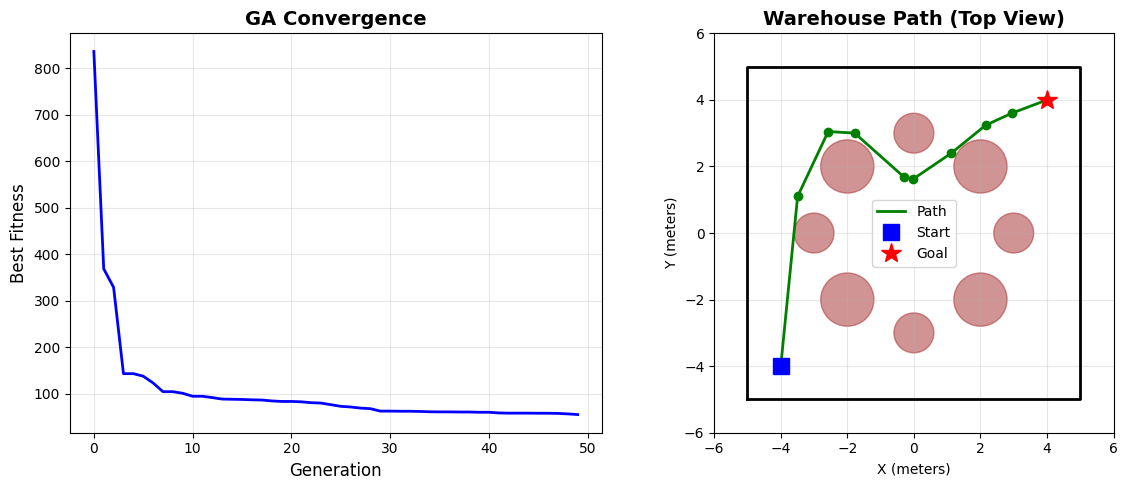

✓ Visualizations complete!


In [ ]:
print("\n[3/5] Creating visualizations...")

# Plot fitness evolution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(planner.fitness_history, linewidth=2, color='blue')
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Best Fitness', fontsize=12)
plt.title('GA Convergence', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Plot 2D warehouse view
plt.subplot(1, 2, 2)
for x, y, radius in obstacles:
    circle = Circle((x, y), radius, color='brown', alpha=0.5)
    plt.gca().add_patch(circle)

plt.plot(best_path[:, 0], best_path[:, 1], 'g-', linewidth=2, label='Path')
plt.plot(best_path[:, 0], best_path[:, 1], 'go', markersize=6)
plt.plot(start_pos[0], start_pos[1], 'bs', markersize=12, label='Start')
plt.plot(goal_pos[0], goal_pos[1], 'r*', markersize=15, label='Goal')
plt.plot([-5, 5, 5, -5, -5], [-5, -5, 5, 5, -5], 'k-', linewidth=2)

plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.gca().set_aspect('equal')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Warehouse Path (Top View)', fontsize=14, fontweight='bold')
plt.xlabel('X (meters)')
plt.ylabel('Y (meters)')

plt.tight_layout()
plt.show()

print("✓ Visualizations complete!")

## 8. Simulate Robot Movement

In [ ]:
print("\n[4/5] Visualizing path in PyBullet...")
sim.visualize_path(best_path)

print("\n[5/5] Simulating robot movement...")
sim.move_robot(best_path, speed=0.5)
print("✓ Robot reached goal!")

# Keep simulation open if GUI enabled
if USE_GUI:
    print("\nSimulation running. Close the PyBullet window when done.")
    while True:
        p.stepSimulation()
        time.sleep(0.01)
else:
    time.sleep(1)
    sim.cleanup()
    print("\n" + "="*60)
    print("SIMULATION COMPLETE!")
    print("="*60)


[4/5] Visualizing path in PyBullet...

[5/5] Simulating robot movement...
✓ Robot reached goal!

SIMULATION COMPLETE!


## 9. Performance Analysis

In [ ]:
# Analyze path quality
print("\n📊 PATH ANALYSIS")
print("="*60)
print(f"Total path length: {path_length:.2f} meters")
print(f"Number of waypoints: {len(best_path)}")
print(f"Average segment length: {path_length/(len(best_path)-1):.2f} meters")

# Check for collisions
collisions = 0
for i in range(len(best_path) - 1):
    for obs_x, obs_y, obs_radius in obstacles:
        obs_pos = np.array([obs_x, obs_y])
        for t in np.linspace(0, 1, 10):
            point = best_path[i] + t * (best_path[i+1] - best_path[i])
            if np.linalg.norm(point - obs_pos) < obs_radius:
                collisions += 1
                break

print(f"Collision-free: {'✓ Yes' if collisions == 0 else '✗ No'}")
print(f"\nGA Performance:")
print(f"  Initial fitness: {planner.fitness_history[0]:.2f}")
print(f"  Final fitness: {planner.fitness_history[-1]:.2f}")
print(f"  Improvement: {(1 - planner.fitness_history[-1]/planner.fitness_history[0])*100:.1f}%")
print("="*60)


📊 PATH ANALYSIS
Total path length: 15.05 meters
Number of waypoints: 10
Average segment length: 1.67 meters
Collision-free: ✓ Yes

GA Performance:
  Initial fitness: 836.62
  Final fitness: 54.69
  Improvement: 93.5%


## 10. Experiment with Different Parameters (Optional)

In [ ]:
# Compare different GA parameters
print("\n🔬 PARAMETER COMPARISON")
print("="*60)

configs = [
    {'pop': 50, 'gen': 30, 'waypoints': 6},
    {'pop': 100, 'gen': 50, 'waypoints': 8},
    {'pop': 150, 'gen': 70, 'waypoints': 10},
]

results = []

for i, config in enumerate(configs):
    print(f"\nConfig {i+1}: Pop={config['pop']}, Gen={config['gen']}, Waypoints={config['waypoints']}")

    planner = GeneticPathPlanner(
        start=start_pos,
        goal=goal_pos,
        obstacles=obstacles,
        warehouse_bounds=bounds,
        population_size=config['pop'],
        num_waypoints=config['waypoints'],
        generations=config['gen']
    )

    path = planner.evolve(verbose=False)
    length = sum([np.linalg.norm(path[i+1] - path[i]) for i in range(len(path)-1)])

    results.append({
        'config': config,
        'length': length,
        'fitness': planner.fitness_history[-1]
    })

    print(f"  Path length: {length:.2f}m")
    print(f"  Final fitness: {planner.fitness_history[-1]:.2f}")

print("\n" + "="*60)
print("Best configuration: Config", np.argmin([r['length'] for r in results]) + 1)
print("="*60)


🔬 PARAMETER COMPARISON

Config 1: Pop=50, Gen=30, Waypoints=6

✓ Evolution complete! Final fitness: 51.42
  Path length: 16.82m
  Final fitness: 51.42

Config 2: Pop=100, Gen=50, Waypoints=8

✓ Evolution complete! Final fitness: 97.75
  Path length: 20.84m
  Final fitness: 97.75

Config 3: Pop=150, Gen=70, Waypoints=10

✓ Evolution complete! Final fitness: 80.29
  Path length: 16.05m
  Final fitness: 80.29

Best configuration: Config 3


**Exercises: **
1. Tune the hyperparameter like generations, population size, mutation rate, cross over technique and observe the results to interpret
2. Implement Ant colony and Particle Swarm optimization. Compare the suitability for path planning in large state/action spaces
3. Explore Neurevolution a way to use evolutionary algorithms to generate artificial neural network. Can DNN learnt be used for path planning? Comment your observartion
